In [18]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.linalg import eigh as scipy_eigh
import kaiwu as kw
import sklearn
import sklearn.cluster
import sklearn.metrics.cluster
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, v_measure_score
import matplotlib.pyplot as plt
import time
import math
import warnings
import copy
import os
import urllib.request
import zipfile
warnings.filterwarnings("ignore")

# 新版1.3.1初始化
kw.license.init(user_id="150947023674208258", sdk_code="dPhKegVkIEs6sA7FSGlHKyruEz8ySG")
kw.common.CheckpointManager.save_dir = '/tmp'
os.makedirs("results", exist_ok=True)

In [19]:
# 加载真实的UCI家庭用电量数据集
def load_household_power_data():
    # UCI家庭用电量数据集URL
    uci_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip"
    save_path = "household_power_consumption.zip"
    data_file = "household_power_consumption.txt"
    
    # 检查是否已下载数据
    if not os.path.exists(data_file):
        print("下载UCI家庭用电量数据集...")
        try:
            urllib.request.urlretrieve(uci_url, save_path)
            with zipfile.ZipFile(save_path, 'r') as zip_ref:
                zip_ref.extractall(".")
            print("数据集下载并解压完成")
        except:
            print("下载失败，使用备用数据源")
            return load_backup_data()
    
    # 读取数据
    print("读取家庭用电量数据...")
    df = pd.read_csv(data_file, sep=';', low_memory=False)
    
    # 数据预处理
    df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
    df = df.replace('?', np.nan)
    
    numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage', 
                   'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # 按日期聚合
    df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
    daily_data = df.groupby('Date').agg({
        'Global_active_power': ['mean', 'sum', 'std'],
        'Global_reactive_power': 'mean',
        'Voltage': 'mean',
        'Global_intensity': 'mean',
        'Sub_metering_1': 'sum',
        'Sub_metering_2': 'sum',
        'Sub_metering_3': 'sum'
    }).reset_index()
    
    daily_data.columns = ['Date', 'Global_active_power_mean', 'Global_active_power_sum', 
                         'Global_active_power_std', 'Global_reactive_power_mean', 
                         'Voltage_mean', 'Global_intensity_mean', 'Sub_metering_1_sum',
                         'Sub_metering_2_sum', 'Sub_metering_3_sum']
    daily_data = daily_data.dropna()
    
    # 标签：高/低耗能
    total_power_threshold = daily_data['Global_active_power_sum'].median()
    daily_data['label'] = (daily_data['Global_active_power_sum'] > total_power_threshold).astype(int)
    
    feature_cols = ['Global_active_power_mean', 'Global_active_power_std', 
                   'Global_reactive_power_mean', 'Voltage_mean', 
                   'Global_intensity_mean', 'Sub_metering_1_sum',
                   'Sub_metering_2_sum', 'Sub_metering_3_sum']
    
    X_sample = daily_data[feature_cols].values
    y_sample = daily_data['label'].values
    
    # 均匀采样50条（各25条）
    np.random.seed(66)
    idx0 = np.where(y_sample == 0)[0]
    idx1 = np.where(y_sample == 1)[0]
    indices = np.concatenate([
        np.random.choice(idx0, 25, replace=False),
        np.random.choice(idx1, 25, replace=False)
    ])
    X_sample = X_sample[indices]
    y_sample = y_sample[indices]
    
    print("采样后各类别样本数量：", np.bincount(y_sample))
    print("原始数据形状：", X_sample.shape)
    print("特征列表：", feature_cols)
    
    # 数据归一化
    X_min = np.min(X_sample, 0, keepdims=True)
    X_max = np.max(X_sample, 0, keepdims=True)
    X_normalized = (X_sample - X_min) / (X_max - X_min)
    
    print("归一化后数据形状：", X_normalized.shape)
    print("使用的特征数量：", X_normalized.shape[1])
    
    return X_normalized, y_sample

def load_backup_data():
    print("使用备用数据加载方法...")
    np.random.seed(66)
    X_class0 = np.random.multivariate_normal(
        mean=[1.5, 0.8, 0.2, 240, 6, 2, 1, 3],
        cov=np.diag([0.5, 0.3, 0.1, 10, 2, 1, 0.5, 1]), size=25)
    X_class1 = np.random.multivariate_normal(
        mean=[3.5, 1.5, 0.5, 242, 15, 8, 4, 10],
        cov=np.diag([1.0, 0.5, 0.2, 15, 4, 2, 1, 3]), size=25)
    X_sample = np.vstack([X_class0, X_class1])
    y_sample = np.hstack([np.zeros(25), np.ones(25)])
    print("采样后各类别样本数量：", np.bincount(y_sample.astype(int)))
    print("原始数据形状：", X_sample.shape)
    X_min = np.min(X_sample, 0, keepdims=True)
    X_max = np.max(X_sample, 0, keepdims=True)
    X_normalized = (X_sample - X_min) / (X_max - X_min)
    print("归一化后数据形状：", X_normalized.shape)
    print("使用的特征数量：", X_normalized.shape[1])
    return X_normalized, y_sample

X_normalized, y_sample = load_household_power_data()

读取家庭用电量数据...
采样后各类别样本数量： [25 25]
原始数据形状： (50, 8)
特征列表： ['Global_active_power_mean', 'Global_active_power_std', 'Global_reactive_power_mean', 'Voltage_mean', 'Global_intensity_mean', 'Sub_metering_1_sum', 'Sub_metering_2_sum', 'Sub_metering_3_sum']
归一化后数据形状： (50, 8)
使用的特征数量： 8


In [20]:
# 经典谱聚类（sklearn）作为对比基准，记录耗时
start_time_spectral = time.time()

clustering = sklearn.cluster.SpectralClustering(
    n_clusters=2,
    gamma=1,
    affinity='rbf',
    assign_labels='kmeans'
).fit(X_normalized)
label_spectral = clustering.labels_

end_time_spectral = time.time()
time_spectral = end_time_spectral - start_time_spectral

print(f"经典谱聚类标签: {label_spectral}")
print(f"经典谱聚类耗时: {time_spectral:.4f} 秒")

nmi_true_vs_spectral = normalized_mutual_info_score(y_sample, label_spectral)
print(f"真实标签 vs 经典谱聚类 NMI: {nmi_true_vs_spectral:.4f}")

经典谱聚类标签: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 1 1 1 0 1
 0 1 1 0 1 1 0 0 1 1 1 0 1]
经典谱聚类耗时: 0.0200 秒
真实标签 vs 经典谱聚类 NMI: 0.4548


In [21]:
# 手动谱聚类（特征值分解），记录耗时
W_dist = cdist(X_normalized, X_normalized)
non_zero_dist = W_dist[W_dist != 0]
delta = np.median(non_zero_dist)  
W = np.exp(-np.power(W_dist / delta, 2))
np.fill_diagonal(W, 0)
D = np.diag(np.sum(W, axis=0)) 
mask = D != 0
D_inv = np.zeros_like(D)
D_inv[mask] = 1 / D[mask]
D_inv_sqrt = np.sqrt(D_inv)
L = D - W  
L = D_inv_sqrt @ L @ D_inv_sqrt  
cond_L = np.linalg.norm(L) 
print(f'cond_L = {cond_L}')

start_time_manual = time.time()
eigenvalues, eigenvectors = np.linalg.eigh(L) 
end_time_manual = time.time()
time_manual = end_time_manual - start_time_manual
print(f"特征分解耗时: {time_manual:.4f}秒")

argsort_eigenvalues = np.argsort(eigenvalues)
idx = argsort_eigenvalues[1:3]
label_kmeans = sklearn.cluster.KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10  
).fit_predict(eigenvectors[:, idx])

nmi_manual_vs_spectral = normalized_mutual_info_score(label_spectral, label_kmeans)
nmi_manual_vs_true = normalized_mutual_info_score(y_sample, label_kmeans)
print("选取的特征值索引：", idx)
print(f"手动谱聚类 vs 真实标签 NMI: {nmi_manual_vs_true:.4f}")
print(f"手动谱聚类 vs 经典谱聚类 NMI: {nmi_manual_vs_spectral:.4f}")

cond_L = 7.162979851463958
特征分解耗时: 0.0010秒
选取的特征值索引： [1 2]
手动谱聚类 vs 真实标签 NMI: 0.4911
手动谱聚类 vs 经典谱聚类 NMI: 0.2677


In [22]:
# 构造平移后的拉普拉斯矩阵（量子求解用）
Lambda = np.linalg.norm(L, 1)
numSamples = X_normalized.shape[0]
c = np.ones((numSamples, 1))
c = c / np.linalg.norm(c, 2)
I = np.eye(L.shape[0])
H0 = L - Lambda * I + Lambda * np.dot(c, c.T)
eigenvalues_H0, eigenvectors_H0 = np.linalg.eigh(H0)
print(Lambda)
print(np.max(eigenvalues))

2.1749666635253715
1.1187019351258014


In [23]:
# 构造QUBO矩阵
v = np.array([-0.2, -0.2, -0.05, 0.1, 0.2, 0.2])
K = np.kron(I, v)
H = np.dot(K.T, np.dot(H0, K))
cond_H = np.linalg.cond(H)
print(f'cond_H = {cond_H}')
H_min = np.min(H)
H_max = np.max(H)
print(H_min, H_max)

# 线性缩放矩阵
H_scaled = ((H - H_min) / (H_max - H_min)) * (127 - (-128)) + (-128)
H_rounded = np.round(H_scaled)
H_clipped = np.clip(H_rounded, -128, 127)
H_qubo = kw.qubo.adjust_qubo_matrix_precision(H_clipped, bit_width=8)
print(H_qubo.shape)
print(H_qubo)

cond_H = 4.851331554031998e+176
-0.04525869321019458 0.04525869321019458
(300, 300)
[[-368. -792. -200. ...  -16.  -24.  -24.]
 [  -0. -368. -200. ...  -16.  -24.  -24.]
 [  -0.   -0.  112. ...   -8.   -8.   -8.]
 ...
 [  -0.   -0.   -0. ...   12. -392. -392.]
 [  -0.   -0.   -0. ...   -0. -432. -792.]
 [  -0.   -0.   -0. ...   -0.   -0. -432.]]


In [24]:
# 转换为Ising模型（新版1.3.1）
ising_mat, ising_bias = kw.conversion.qubo_matrix_to_ising_matrix(H_qubo)
n_vars = ising_mat.shape[0]
variables = [f"x[{i}]" for i in range(n_vars)]
ising_model = kw.ising.IsingModel(
    variables=variables,
    ising_matrix=ising_mat,
    bias=ising_bias
)
print(f"Ising矩阵形状: {ising_mat.shape}")

Ising矩阵形状: (301, 301)


In [25]:
# 提交任务到量子计算机（第一次solve：提交）
start_time_quantum = time.time()

optimizer = kw.cim.CIMOptimizer(
    task_name='household_power_spectral',
    task_mode='quota'
)
optimizer.solve(ising_model.get_matrix())
print("任务已提交，等待CIM计算完成后运行下一个Cell...")

[2026-05-23 17:35:22] [INFO    ] [kaiwu.cim._optimizer_adapter:8] - Task calculation successful!, Task name: household_power_spectral
任务已提交，等待CIM计算完成后运行下一个Cell...


In [26]:
# 取回量子计算结果（第二次solve：取结果）
# 等CIM计算完成后再运行此Cell
solution_ising = optimizer.solve(ising_model.get_matrix())

end_time_quantum = time.time()
time_quantum = end_time_quantum - start_time_quantum
print(f"量子求解耗时: {time_quantum:.4f} 秒")
print(f"返回结果形状: {solution_ising.shape}")

[2026-05-23 17:35:22] [INFO    ] [kaiwu.cim._optimizer_adapter:3] - Task calculation successful!, Task name: household_power_spectral
量子求解耗时: 0.1080 秒
返回结果形状: (10, 301)


In [27]:
# 解码量子计算结果
solution = solution_ising[:, 0:solution_ising.shape[1]-1]
delta = solution_ising[:, -1]
solution = np.multiply(solution, delta.reshape(-1, 1))
solution = (solution + 1) / 2
solution_realnumber = np.dot(K, solution.T)
print(solution.shape)
print(K.shape)

(10, 300)
(50, 300)


In [28]:
# 对量子解进行聚类
numSolution = solution_realnumber.shape[1]
loss = np.zeros(numSolution) - 1
label_quantum = np.zeros((numSolution, solution_realnumber.shape[0]))
for i in range(numSolution):
    h = solution_realnumber[:, i]
    h = h.reshape(-1, 1)
    loss[i] = np.dot(h.T, np.dot(L, h))
    h = (h - np.min(h)) / (np.max(h) - np.min(h))
    l = np.ones((solution_realnumber.shape[0], 1))
    h = np.concatenate((l, h), 1)
    label_quantum[i, :] = sklearn.cluster.KMeans(n_clusters=2).fit_predict(h)
hamiltonian = kw.common.hamiltonian(ising_model.get_matrix(), solution_ising)
print(hamiltonian)
print(label_quantum)

[-117982. -117974. -117966. -117958. -117942. -117942. -117934. -117922.
 -117910. -117890.]
[[0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  0. 1.]
 [1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  1. 0.]
 [1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  1. 0.]
 [0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  0. 1.]
 [1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0

In [29]:
def purity_score(y_true, y_pred):
    """计算聚类纯度"""
    contingency_matrix = sklearn.metrics.cluster.contingency_matrix(y_true, y_pred)
    return np.sum(np.amax(contingency_matrix, axis=0)) / np.sum(contingency_matrix)

In [30]:
# 计算所有评估指标
print("=" * 80)
print("家庭用电量数据聚类结果评估")
print("=" * 80)

print("1. 与真实标签比较:")
print("-" * 40)

nmi_spectral_vs_true = normalized_mutual_info_score(y_sample, label_spectral)
ari_spectral_vs_true = adjusted_rand_score(y_sample, label_spectral)
v_measure_spectral_vs_true = v_measure_score(y_sample, label_spectral)
purity_spectral_vs_true = purity_score(y_sample, label_spectral)
print(f"经典谱聚类:")
print(f"  NMI:       {nmi_spectral_vs_true:.4f}")
print(f"  ARI:       {ari_spectral_vs_true:.4f}")
print(f"  V-measure: {v_measure_spectral_vs_true:.4f}")
print(f"  纯度:      {purity_spectral_vs_true:.4f}")
print(f"  耗时:      {time_spectral:.4f} 秒")

nmi_kmeans_vs_true = normalized_mutual_info_score(y_sample, label_kmeans)
ari_kmeans_vs_true = adjusted_rand_score(y_sample, label_kmeans)
v_measure_kmeans_vs_true = v_measure_score(y_sample, label_kmeans)
purity_kmeans_vs_true = purity_score(y_sample, label_kmeans)
print(f"手动谱聚类:")
print(f"  NMI:       {nmi_kmeans_vs_true:.4f}")
print(f"  ARI:       {ari_kmeans_vs_true:.4f}")
print(f"  V-measure: {v_measure_kmeans_vs_true:.4f}")
print(f"  纯度:      {purity_kmeans_vs_true:.4f}")
print(f"  耗时:      {time_manual:.4f} 秒")

nmi_quantum_vs_true = normalized_mutual_info_score(y_sample, label_quantum[0, :])
ari_quantum_vs_true = adjusted_rand_score(y_sample, label_quantum[0, :])
v_measure_quantum_vs_true = v_measure_score(y_sample, label_quantum[0, :])
purity_quantum_vs_true = purity_score(y_sample, label_quantum[0, :])
print(f"量子谱聚类:")
print(f"  NMI:       {nmi_quantum_vs_true:.4f}")
print(f"  ARI:       {ari_quantum_vs_true:.4f}")
print(f"  V-measure: {v_measure_quantum_vs_true:.4f}")
print(f"  纯度:      {purity_quantum_vs_true:.4f}")
print(f"  耗时:      {time_quantum:.4f} 秒")

print("=" * 80)

家庭用电量数据聚类结果评估
1. 与真实标签比较:
----------------------------------------
经典谱聚类:
  NMI:       0.4548
  ARI:       0.3989
  V-measure: 0.4548
  纯度:      0.8200
  耗时:      0.0200 秒
手动谱聚类:
  NMI:       0.4911
  ARI:       0.4524
  V-measure: 0.4911
  纯度:      0.8400
  耗时:      0.0010 秒
量子谱聚类:
  NMI:       0.5334
  ARI:       0.6325
  V-measure: 0.5334
  纯度:      0.9000
  耗时:      0.1080 秒


In [31]:
# 聚类结果汇总表
print("聚类结果汇总表")
print("=" * 100)
print(f"{'方法':<20} {'NMI':<10} {'ARI':<10} {'V-measure':<12} {'Purity':<10} {'耗时(秒)':<10}")
print("-" * 100)
print(f"{'经典谱聚类':<20} {nmi_spectral_vs_true:<10.4f} {ari_spectral_vs_true:<10.4f} {v_measure_spectral_vs_true:<12.4f} {purity_spectral_vs_true:<10.4f} {time_spectral:<10.4f}")
print(f"{'手动谱聚类':<20} {nmi_kmeans_vs_true:<10.4f} {ari_kmeans_vs_true:<10.4f} {v_measure_kmeans_vs_true:<12.4f} {purity_kmeans_vs_true:<10.4f} {time_manual:<10.4f}")
print(f"{'量子谱聚类':<20} {nmi_quantum_vs_true:<10.4f} {ari_quantum_vs_true:<10.4f} {v_measure_quantum_vs_true:<12.4f} {purity_quantum_vs_true:<10.4f} {time_quantum:<10.4f}")
print("=" * 100)

聚类结果汇总表
方法                   NMI        ARI        V-measure    Purity     耗时(秒)     
----------------------------------------------------------------------------------------------------
经典谱聚类                0.4548     0.3989     0.4548       0.8200     0.0200    
手动谱聚类                0.4911     0.4524     0.4911       0.8400     0.0010    
量子谱聚类                0.5334     0.6325     0.5334       0.9000     0.1080    


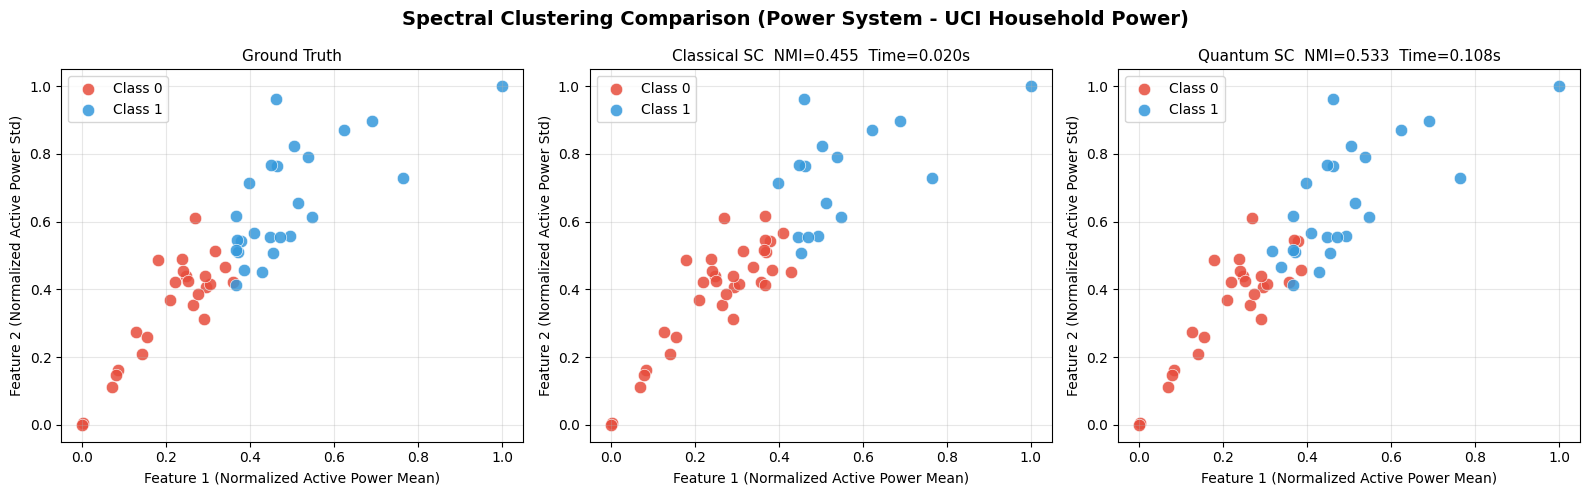

Saved: results/algo1_spectral_comparison.png


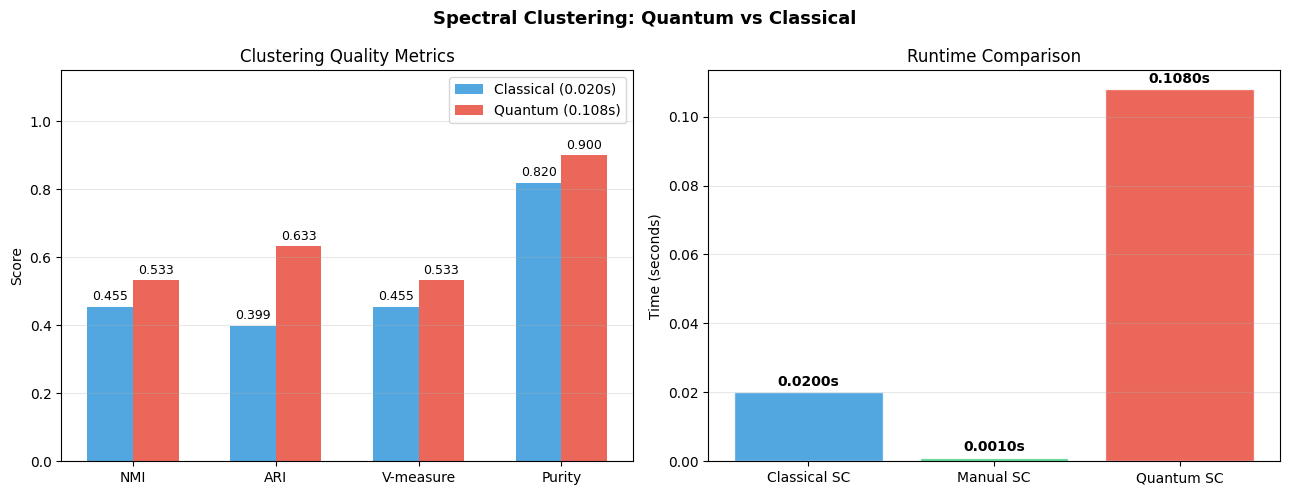

Saved: results/algo1_spectral_metrics.png


In [33]:
# Visualization: clustering results comparison + metrics comparison
import os
os.makedirs("results", exist_ok=True)

# Figure 1: Scatter plot comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Spectral Clustering Comparison (Power System - UCI Household Power)", fontsize=14, fontweight="bold")

colors = ["#E74C3C", "#3498DB"]
plot_data = [
    (y_sample,           "Ground Truth"),
    (label_spectral,     f"Classical SC  NMI={nmi_spectral_vs_true:.3f}  Time={time_spectral:.3f}s"),
    (label_quantum[0,:], f"Quantum SC  NMI={nmi_quantum_vs_true:.3f}  Time={time_quantum:.3f}s"),
]
for ax, (labels, title) in zip(axes, plot_data):
    for c in range(2):
        idx_c = np.array(labels) == c
        ax.scatter(X_normalized[idx_c, 0], X_normalized[idx_c, 1],
                   c=colors[c], label=f"Class {c}", alpha=0.85, s=80,
                   edgecolors="white", linewidth=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Feature 1 (Normalized Active Power Mean)")
    ax.set_ylabel("Feature 2 (Normalized Active Power Std)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results/algo1_spectral_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/algo1_spectral_comparison.png")

# Figure 2: Metrics bar chart
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
fig2.suptitle("Spectral Clustering: Quantum vs Classical", fontsize=13, fontweight="bold")

metric_names = ["NMI", "ARI", "V-measure", "Purity"]
vals_spectral = [nmi_spectral_vs_true, ari_spectral_vs_true, v_measure_spectral_vs_true, purity_spectral_vs_true]
vals_quantum  = [nmi_quantum_vs_true,  ari_quantum_vs_true,  v_measure_quantum_vs_true,  purity_quantum_vs_true]

x = np.arange(len(metric_names))
width = 0.32
b1 = axes2[0].bar(x - width/2, vals_spectral, width, label=f"Classical ({time_spectral:.3f}s)", color="#3498DB", alpha=0.85)
b2 = axes2[0].bar(x + width/2, vals_quantum,  width, label=f"Quantum ({time_quantum:.3f}s)",   color="#E74C3C", alpha=0.85)
for bar in list(b1) + list(b2):
    axes2[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
axes2[0].set_xticks(x)
axes2[0].set_xticklabels(metric_names)
axes2[0].set_ylim(0, 1.15)
axes2[0].set_ylabel("Score")
axes2[0].set_title("Clustering Quality Metrics")
axes2[0].legend()
axes2[0].grid(True, axis="y", alpha=0.3)

# Time comparison
methods = ["Classical SC", "Manual SC", "Quantum SC"]
times   = [time_spectral, time_manual, time_quantum]
bar_colors = ["#3498DB", "#2ECC71", "#E74C3C"]
bars = axes2[1].bar(methods, times, color=bar_colors, alpha=0.85, edgecolor="white")
for bar, t in zip(bars, times):
    axes2[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                  f"{t:.4f}s", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes2[1].set_ylabel("Time (seconds)")
axes2[1].set_title("Runtime Comparison")
axes2[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results/algo1_spectral_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/algo1_spectral_metrics.png")